# Ingeniería de características (Feature Engineering) para HAR con sEMG

**Objetivo:** convertir las grabaciones sEMG crudas en una tabla de variables útiles para aprendizaje automático, y después reducir esa tabla con métodos de filtrado (selección) y de extracción de características, justificando cada decisión.

**Unidad de análisis:** las **mismas ventanas etiquetadas que `01_Pipeline_CPC.ipynb`** (sección 5.3, con `TARGET_FS = 50` Hz):

- ventanas de **4 s** que terminan cada **0.5 s**;
- la etiqueta de la ventana es la clase en su **último instante**;
- sujetos 1–12 para entrenar y sujetos **13 y 14** para probar.

Usar exactamente las mismas ventanas, el mismo split y el mismo clasificador (regresión logística con `class_weight="balanced"`) permite comparar al final las features diseñadas a mano con la representación aprendida por CPC (F1 macro 0.475 con GRU y K=20) y con las "features crudas" del notebook 01 (F1 0.319).

| Sección | Contenido | Rúbrica |
| :--- | :--- | :--- |
| 1–2 | Setup, catálogo de datos y exclusiones del EDA | — |
| 3 | Generación de características desde la señal | Generación de nuevas características |
| 4 | Codificación y discretización de variables de contexto | Codificación, discretización |
| 5 | Transformaciones para reducir la asimetría | Transformación |
| 6 | Escalamiento | Escalamiento |
| 7 | Selección por filtrado | Varianza, correlación, ANOVA, chi-cuadrado (+ información mutua) |
| 8 | Extracción de características | PCA, análisis factorial |
| 9 | Comparación: ¿cuánto se pierde y cuánto se ahorra? | Almacenamiento, complejidad y tiempo |
| 10 | Conclusiones | — |

**Regla general para evitar fuga de información:** todo lo que "aprende" de los datos (parámetros de las transformaciones, escaladores, umbrales, rankings de selección, PCA y FA) se ajusta **sólo con los sujetos de entrenamiento** y después se aplica a los de prueba.

# 1. Setup

La extracción de características recorre los ~640 ensayos (10 GB de CSV) y tarda algunos minutos. El resultado se guarda en `_cache/fe_window_features.pkl`; con `REFRESH = True` se recalcula.

In [1]:
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import KBinsDiscretizer, MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler

SEED = 0
REFRESH = False                      # True: recalcular las características aunque exista el caché

# --- Rutas (mismo layout que 00_EDA_dataset.ipynb y 01_Pipeline_CPC.ipynb) ---
ROOT = Path.cwd().resolve().parent
DATA_ROOT = ROOT / "datos_unzipped"
EMG_DIR, LABEL_DIR = DATA_ROOT / "Data", DATA_ROOT / "Labels"
SUBJ_XLSX = ROOT / "datos" / "Subjs_info.xlsx"
CACHE_DIR = Path.cwd() / "_cache"
FEATURES_PKL = CACHE_DIR / "fe_window_features.pkl"
assert EMG_DIR.exists(), f"No encontrado: {EMG_DIR} (ejecuta este notebook desde notebooks/)"

# --- Ventanas: idénticas a 01_Pipeline_CPC.ipynb con TARGET_FS = 50 Hz ---
FS_ENV = 50                          # Hz de la rejilla de la envolvente Norm_RMS
WINDOW_S, HOP_S, LOCAL_S = 4.0, 0.5, 1.0
WINDOW_LEN = int(FS_ENV * WINDOW_S)  # 200 pasos = 4 s de contexto
EVAL_HOP = int(FS_ENV * HOP_S)       # 25 pasos = una ventana cada 0.5 s
LOCAL_LEN = int(FS_ENV * LOCAL_S)    # 50 pasos = último segundo de la ventana

# --- Filtrado del EMG crudo (como Process.m de los autores, ver sección 3) ---
EMG_BAND = (20.0, 180.0)             # Hz; 180 < Nyquist del archivo más lento (366.7 / 2 = 183 Hz)
NOTCH_HZ = 50.0                      # interferencia de la red eléctrica

CH = list(range(1, 9))
RAW = [f"Raw_V_{c}" for c in CH]
NORM_RMS = [f"Norm_RMS_{c}" for c in CH]
LABEL_ORDER = ["N", "LF", "K", "PT", "LT", "W", "PF"]
VAL_SUBJECTS = {13, 14}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
CLASS_COLORS = dict(zip(LABEL_ORDER, ["#9e9e9e", "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860"]))

# 2. Catálogo de ensayos y exclusiones

Se aplican las mismas decisiones del EDA y del notebook 01:

- **Sólo ensayos:** las grabaciones MVC son sólo la referencia de normalización, no actividades.
- **Se excluyen los 3 archivos con canales rotos** (desviación estándar > 50 mV en algún canal, sujeto 7).
- **Se excluyen los 2 archivos con etiquetas inconsistentes** (segmentos vacíos o solapados).

El nombre de cada archivo codifica la **tarea**, el **lado**, la **carga** y la **condición**. Esos metadatos se usan en la sección 4.

In [2]:
EMG_RE = re.compile(
    r"Subj_(?P<subject>\d+)_(?:(?P<mvc>MVC)_)?(?P<task>Isokin|MMH_Bim|MMH_One|All)_(?P<side>[LR])"
    r"(?:_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d))?_EMG_data\.csv"
)

rows = []
for p in sorted(EMG_DIR.glob("Subj_*/*.csv")):
    m = EMG_RE.fullmatch(p.name)
    if m is None:
        raise ValueError(f"Nombre de archivo inesperado: {p.name}")
    d = m.groupdict()
    rows.append(dict(file=p.name, path=p, subject=int(d["subject"]), task=d["task"], side=d["side"],
                     load_kg=float(d["load_kg"]) if d["load_kg"] else np.nan, condition=d["condition"],
                     is_mvc=d["mvc"] is not None))
catalog = pd.DataFrame(rows)
trials = catalog[~catalog.is_mvc].copy()

# Archivos con canales rotos (sección 6 del EDA)
file_stats = pd.read_csv(CACHE_DIR / "emg_file_stats.csv")
std_max_mV = file_stats[[f"raw_std_{c}" for c in CH]].max(axis=1) * 1e3
BAD_EMG_FILES = set(file_stats.loc[std_max_mV > 50, "file"])


def label_file(row):
    return LABEL_DIR / row.path.parent.name / row.file.replace("_EMG_data.csv", "_EMG_labels.csv")


def labels_are_consistent(lab):
    """Misma regla del EDA: ningún segmento vacío/invertido ni solapado con el siguiente."""
    gap_to_next = lab.Start_Frame.shift(-1) - lab.End_Frame
    return not ((lab.End_Frame < lab.Start_Frame).any() or (gap_to_next < 0).any())


labels = {row.file: pd.read_csv(label_file(row)) for row in trials.itertuples()}
BAD_LABEL_FILES = {f for f, lab in labels.items() if not labels_are_consistent(lab)}

trials = trials[~trials.file.isin(BAD_EMG_FILES | BAD_LABEL_FILES)].reset_index(drop=True)
print(f"{len(trials)} ensayos utilizables  (excluidos: {len(BAD_EMG_FILES)} con canales rotos, "
      f"{len(BAD_LABEL_FILES)} con etiquetas inconsistentes)")
trials.groupby("task").agg(ensayos=("file", "size"), sujetos=("subject", "nunique"),
                           cargas_kg=("load_kg", lambda s: sorted(s.unique())),
                           condiciones=("condition", lambda s: sorted(s.unique())))

638 ensayos utilizables  (excluidos: 3 con canales rotos, 2 con etiquetas inconsistentes)


,ensayos,sujetos,cargas_kg,condiciones
task,,,,
Isokin,222,14,"[2.0, 4.0]","[40bpm, 60bpm, 80bpm, St]"
MMH_Bim,249,14,"[2.0, 8.0, 12.0]","[Trial_1, Trial_2, Trial_3]"
MMH_One,167,14,"[2.0, 4.0]","[Trial_1, Trial_2, Trial_3]"


# 3. Generación de características

Las features se calculan para cada ventana y se agrupan en tres familias, cada una con una justificación distinta.

### 3.1 Activación muscular (envolvente `Norm_RMS`, %MVC)

`Norm_RMS` es la envolvente RMS (250 ms) normalizada por la MVC de cada sujeto. Es la señal más limpia del dataset (EDA, secciones 6–8) y la que mejor separa reposo de actividad.

- **En el último segundo de la ventana** (cerca del instante que se etiqueta): media, desviación estándar, mínimo, máximo y **pendiente** en %MVC/s. La pendiente distingue una activación que crece, como al levantar (`LF`, `LT`), de una que decrece, como al soltar (`PT`, `PF`).
- **En los 4 s completos (contexto):** media, desviación estándar y pendiente. Aportan la historia reciente, que es justo lo que resume el contexto $c_t$ de CPC.

### 3.2 Patrón entre canales (independiente de la escala)

- **`share_chX`:** la fracción de la activación total que aporta cada canal. La amplitud cambia mucho con la carga y entre sujetos (EDA, secciones 6 y 8), pero el reparto entre músculos depende más del **tipo de movimiento** que de la fuerza.
- **`act_total`:** la activación media de los 8 canales.
- **`act_spread`:** el coeficiente de variación entre canales, es decir, qué tan desigual es la activación.
- **`act_change`:** la activación del último segundo menos la de los 4 s.

### 3.3 Forma de onda y frecuencia (EMG crudo `Raw_V`, último segundo)

La envolvente pierde la información de frecuencia del EMG, así que se recupera del canal crudo. Antes se filtra como en el `Process.m` de los autores:

- **Filtro *notch* de 50 Hz** contra la interferencia de la red eléctrica.
- **Pasa-banda Butterworth de 20 Hz**, que elimina el *offset* y la deriva que el EDA encontró en `Raw_V`.
- **Corte superior en 180 Hz** para todos los archivos: la frecuencia de muestreo varía entre 367 y 1006 Hz, y 180 Hz queda por debajo del Nyquist del archivo más lento. Así todas las features espectrales se calculan **en la misma banda**.
- **Filtrado de fase cero (`filtfilt`)**, que no desplaza la señal en el tiempo.

Sobre el último segundo filtrado se calculan:

- **`zc`** (cruces por cero por segundo) y **`ssc`** (cambios de signo de la pendiente por segundo): descriptores clásicos de Hudgins del contenido de frecuencia. Para no contar ruido se usa un umbral de 5% de la desviación estándar del canal **en ese ensayo**; un umbral absoluto no serviría, porque la amplitud cruda varía ~10× entre sujetos.
- **`mnf`** (frecuencia media) y **`mdf`** (frecuencia mediana) del espectro de potencia (ventana de Hann). Dependen de la velocidad de conducción y del reclutamiento de fibras, y por lo tanto de la fuerza y del tipo de contracción.

No se usan amplitudes del EMG crudo, porque están en voltios y no son comparables entre sujetos. La amplitud ya está representada, normalizada, en la familia 3.1.

In [3]:
def emg_filter(raw, fs):
    """Notch 50 Hz + pasa-banda Butterworth (orden 4) 20-180 Hz, ambos de fase cero. raw: (8, N)."""
    b_n, a_n = signal.iirnotch(NOTCH_HZ, Q=30, fs=fs)
    sos_bp = signal.butter(4, EMG_BAND, btype="bandpass", fs=fs, output="sos")
    return signal.sosfiltfilt(sos_bp, signal.filtfilt(b_n, a_n, raw, axis=1), axis=1)


def slope(x, dt):
    """Pendiente de mínimos cuadrados sobre el último eje, en unidades por segundo."""
    L = x.shape[-1]
    t = (np.arange(L) - (L - 1) / 2) * dt
    return (x * t).sum(-1) / (t ** 2).sum()


def zc_ssc_rate(x, thr, dur):
    """Cruces por cero y cambios de signo de la pendiente por segundo. x: (n, 8, L), thr: (8,)."""
    th = thr[None, :, None]
    d = np.diff(x, axis=-1)
    zc = ((x[..., :-1] * x[..., 1:] < 0) & (np.abs(d) >= th)).sum(-1) / dur
    d1, d2 = d[..., :-1], d[..., 1:]                     # x_i - x_{i-1} y x_{i+1} - x_i
    ssc = ((d1 * d2 < 0) & ((np.abs(d1) >= th) | (np.abs(d2) >= th))).sum(-1) / dur
    return zc, ssc


def mnf_mdf(x, fs):
    """Frecuencia media y mediana del espectro de potencia en EMG_BAND. x: (n, 8, L)."""
    L = x.shape[-1]
    P = np.abs(np.fft.rfft(x * np.hanning(L), axis=-1)) ** 2
    f = np.fft.rfftfreq(L, 1 / fs)
    band = (f >= EMG_BAND[0]) & (f <= EMG_BAND[1])
    P, f = P[..., band], f[band]
    total = P.sum(-1)
    mnf = (P * f).sum(-1) / total
    mdf = f[np.argmax(np.cumsum(P, axis=-1) >= total[..., None] / 2, axis=-1)]
    return mnf, mdf


def trial_features(row, lab):
    """Una fila por ventana etiquetada del ensayo: metadatos + etiqueta + 107 características."""
    d = pd.read_csv(row.path, usecols=["Time"] + RAW + NORM_RMS)
    t = (d["Time"].to_numpy() - d["Time"].iloc[0]) / 1000.0          # s desde el inicio
    fs = (len(t) - 1) / t[-1]                                        # frecuencia propia del archivo

    # Envolvente en una rejilla uniforme de 50 Hz y etiqueta de cada paso (igual que 01_Pipeline_CPC)
    t_grid = np.arange(0, t[-1], 1.0 / FS_ENV)
    if len(t_grid) < WINDOW_LEN:
        return None
    env = np.stack([np.interp(t_grid, t, d[c].to_numpy()) for c in NORM_RMS])        # (8, G)
    y_rows = np.full(len(t), -1)
    for s0, s1, name in lab[["Start_Frame", "End_Frame", "Label"]].itertuples(index=False):
        y_rows[s0:s1 + 1] = LABEL_ORDER.index(name)
    y_grid = y_rows[np.clip(np.searchsorted(t, t_grid), 0, len(t) - 1)]

    # Ventanas de 4 s que terminan cada 0.5 s; se conservan las que terminan en un instante etiquetado
    ends = np.arange(WINDOW_LEN - 1, len(t_grid), EVAL_HOP)
    ends = ends[y_grid[ends] >= 0]
    if len(ends) == 0:
        return None
    win = np.lib.stride_tricks.sliding_window_view(env, WINDOW_LEN, axis=1)            # (8, G-W+1, W)
    ctx = win[:, ends - (WINDOW_LEN - 1), :].transpose(1, 0, 2)                       # (n, 8, 200)
    loc = ctx[..., -LOCAL_LEN:]                                                        # (n, 8, 50)
    dt = 1.0 / FS_ENV

    F = {}
    def add(name, values):                                   # values: (n, 8) -> 8 columnas name_chX
        for c in range(8):
            F[f"{name}_ch{c + 1}"] = values[:, c]

    # 3.1 Activación (Norm_RMS)
    add("act_mean", loc.mean(-1)); add("act_std", loc.std(-1)); add("act_min", loc.min(-1))
    add("act_max", loc.max(-1)); add("act_slope", slope(loc, dt))
    add("ctx_mean", ctx.mean(-1)); add("ctx_std", ctx.std(-1)); add("ctx_slope", slope(ctx, dt))
    # 3.2 Patrón entre canales
    loc_mean = loc.mean(-1)
    add("share", loc_mean / loc_mean.sum(1, keepdims=True))
    F["act_total"] = loc_mean.mean(1)
    F["act_spread"] = loc_mean.std(1) / loc_mean.mean(1)
    F["act_change"] = loc_mean.mean(1) - ctx.mean(-1).mean(1)
    # 3.3 Forma de onda y frecuencia (Raw_V filtrado, último segundo, frecuencia original)
    raw_f = emg_filter(d[RAW].to_numpy().T, fs)                                       # (8, N)
    n_loc = int(round(fs * LOCAL_S))
    end_idx = np.searchsorted(t, t_grid[ends], side="right")                          # muestras con t <= t_end
    seg = raw_f[:, end_idx[:, None] - n_loc + np.arange(n_loc)].transpose(1, 0, 2)    # (n, 8, n_loc)
    zc, ssc = zc_ssc_rate(seg, 0.05 * raw_f.std(axis=1), LOCAL_S)
    mnf, mdf = mnf_mdf(seg, fs)
    add("zc", zc); add("ssc", ssc); add("mnf", mnf); add("mdf", mdf)

    meta = dict(file=row.file, subject=row.subject, task=row.task, side=row.side, load_kg=row.load_kg,
                condition=row.condition, fs_hz=fs)
    out = pd.DataFrame(F)
    out.insert(0, "label", np.array(LABEL_ORDER)[y_grid[ends]])
    out.insert(0, "t_end_s", t_grid[ends])
    for k, v in reversed(meta.items()):
        out.insert(0, k, v)
    return out


if FEATURES_PKL.exists() and not REFRESH:
    df = pd.read_pickle(FEATURES_PKL)
    print(f"Cargado {FEATURES_PKL.name}")
else:
    t0, parts = time.time(), []
    for i, row in enumerate(trials.itertuples()):
        part = trial_features(row, labels[row.file])
        if part is not None:
            parts.append(part)
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(trials)} ensayos  ({time.time() - t0:.0f} s)")
    df = pd.concat(parts, ignore_index=True)
    df.to_pickle(FEATURES_PKL)
    print(f"Características calculadas en {time.time() - t0:.0f} s y guardadas en {FEATURES_PKL.name}")

META_COLS = ["file", "subject", "task", "side", "load_kg", "condition", "fs_hz", "t_end_s", "label"]
FEATURES = [c for c in df.columns if c not in META_COLS]
is_test = df.subject.isin(VAL_SUBJECTS).to_numpy()
y = df.label.map({c: i for i, c in enumerate(LABEL_ORDER)}).to_numpy()
print(f"{len(df)} ventanas x {len(FEATURES)} características  |  train {(~is_test).sum()} (sujetos 1-12), "
      f"test {is_test.sum()} (sujetos 13-14)")
print(f"NaN: {int(df[FEATURES].isna().sum().sum())}  |  infinitos: {int(np.isinf(df[FEATURES].to_numpy()).sum())}")

Cargado fe_window_features.pkl
62121 ventanas x 107 características  |  train 53220 (sujetos 1-12), test 8901 (sujetos 13-14)
NaN: 0  |  infinitos: 0


**Comprobación de comparabilidad:** el notebook 01 (a 50 Hz) generó **62,121 ventanas etiquetadas** (53,220 de entrenamiento y 8,901 de prueba). Si el número de arriba coincide, estas features describen exactamente las mismas ventanas que evaluó el *linear probe* de CPC.

Las familias de características quedan así:

In [4]:
def family(col):
    if col.startswith(("act_mean", "act_std", "act_min", "act_max", "act_slope")):
        return "activación (último s)"
    if col.startswith("ctx_"):
        return "activación (contexto 4 s)"
    if col.startswith("share") or col in ("act_total", "act_spread", "act_change"):
        return "patrón entre canales"
    return "forma de onda / frecuencia (EMG crudo)"


FAMILY = {c: family(c) for c in FEATURES}
pd.Series(FAMILY).value_counts().rename("n características").to_frame()

,n características
activación (último s),40
forma de onda / frecuencia (EMG crudo),32
activación (contexto 4 s),24
patrón entre canales,11


### 3.4 ¿Las características nuevas distinguen las actividades?

Una primera mirada a tres de ellas por clase, con los sujetos de entrenamiento:

- **`act_total`** (escala log) debería separar `N` (reposo) del resto.
- **`act_change`** debería separar las acciones que aumentan la activación (levantar) de las que la reducen (colocar).
- **`mnf`** promedio de los 8 canales: la frecuencia media del EMG.

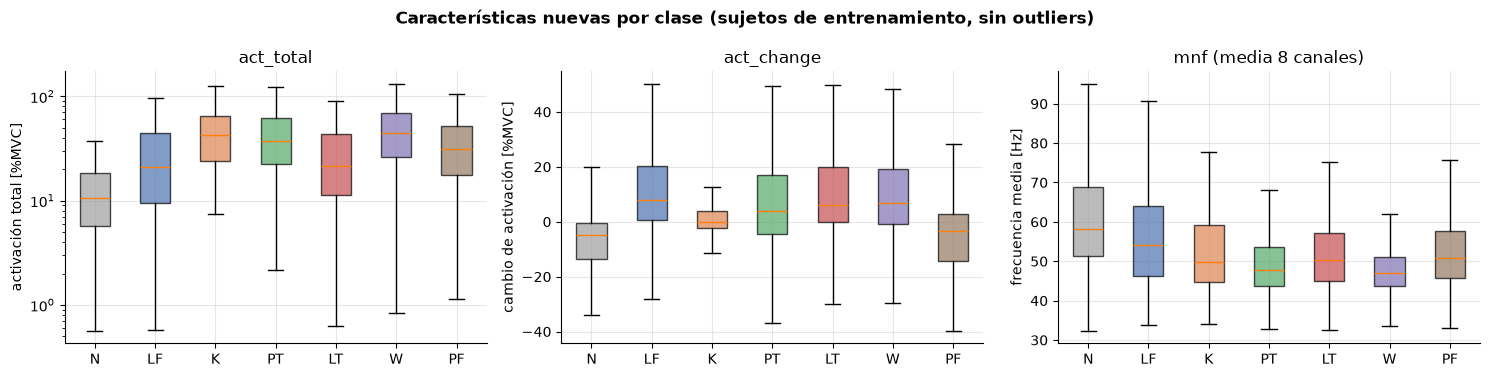

In [5]:
train_df = df[~is_test]
panels = [("act_total", train_df.act_total, "activación total [%MVC]", True),
          ("act_change", train_df.act_change, "cambio de activación [%MVC]", False),
          ("mnf (media 8 canales)", train_df[[f"mnf_ch{c}" for c in CH]].mean(axis=1), "frecuencia media [Hz]", False)]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (title, values, ylabel, log) in zip(axes, panels):
    data = [values[train_df.label == c].to_numpy() for c in LABEL_ORDER]
    bp = ax.boxplot(data, tick_labels=LABEL_ORDER, showfliers=False, patch_artist=True)
    for patch, c in zip(bp["boxes"], LABEL_ORDER):
        patch.set_facecolor(CLASS_COLORS[c]); patch.set_alpha(0.7)
    ax.set(title=title, ylabel=ylabel)
    if log:
        ax.set_yscale("log")
fig.suptitle("Características nuevas por clase (sujetos de entrenamiento, sin outliers)", fontweight="bold")
fig.tight_layout()

# 4. Codificación y discretización

Además de la señal, cada ventana tiene **variables de contexto**: las del ensayo, que vienen del nombre del archivo, y las del sujeto, que vienen de `Subjs_info.xlsx`. Cada tipo de variable requiere una codificación distinta:

| Variable | Tipo | Codificación | Justificación |
| :--- | :--- | :--- | :--- |
| `label` (objetivo) | nominal, 7 clases | entero 0–6 en el orden `N, LF, K, PT, LT, W, PF` | Los clasificadores de scikit-learn esperan la clase como entero; **no implica orden**, por eso no se usa como variable numérica. |
| `task` | nominal (3) | *one-hot* | No hay orden entre `Isokin`, `MMH_Bim` y `MMH_One`; una codificación ordinal inventaría distancias falsas. |
| `side` | binaria | 0 = L, 1 = R | Dos categorías bastan con una sola columna. |
| `condition` → ritmo | ordinal | `St` = 0, 40 / 60 / 80 bpm = 1 / 2 / 3 | En `Isokin` el ritmo del metrónomo tiene un orden natural de velocidad. En MMH la condición es sólo el número de repetición (`Trial_1..3`), no aporta información y se codifica 0 (la columna de tarea ya distingue los casos). |
| `load_kg` | numérica (2, 4, 8, 12) | se conserva **y** se discretiza | Ver la discretización abajo. |
| `Sex` | binaria | 0 = M, 1 = F | |
| `Body_mass`, `Body_height` | numéricas | se combinan en **IMC** (nueva característica) | El IMC resume la complexión en una sola variable. |

**Discretización de la carga:** el EDA (sección 8) mostró que la activación crece con la carga. Los niveles del protocolo son naturales: **ligera** (2–4 kg, las cargas a una mano), **media** (8 kg) y **pesada** (12 kg). Se codifican como ordinal 0 / 1 / 2.

**Advertencia sobre el contexto:** la tarea y la carga son información del **protocolo**, no de la señal. Por ejemplo, `Isokin` sólo contiene `N`, `LT`, `PT` y `K`. Usarlas como entrada "ayuda" al clasificador con algo que en una aplicación real no se conocería. Por eso se mantienen **separadas** de las features de señal, y en la sección 9 se evalúa su efecto aparte.

In [6]:
subj = pd.read_excel(SUBJ_XLSX).set_index("ID")

# Objetivo: entero 0-6 en el orden de LABEL_ORDER (nominal)
target_map = pd.DataFrame({"clase": LABEL_ORDER, "código": range(len(LABEL_ORDER))})

# Tarea: one-hot (nominal)
onehot = OneHotEncoder(sparse_output=False)
task_oh = pd.DataFrame(onehot.fit_transform(df[["task"]]), columns=onehot.get_feature_names_out(), index=df.index)

ctx_df = pd.concat([
    task_oh,
    pd.DataFrame({
        "side_R": (df.side == "R").astype(int),
        "ritmo": df.condition.map({"St": 0, "40bpm": 1, "60bpm": 2, "80bpm": 3}).fillna(0).astype(int),
        "load_kg": df.load_kg,
        "carga_nivel": pd.cut(df.load_kg, bins=[0, 4, 8, 12], labels=[0, 1, 2]).astype(int),   # discretización
        "sex_F": df.subject.map(subj.Sex.eq("F").astype(int)),
        "imc": df.subject.map(subj.Body_mass / (subj.Body_height / 100) ** 2),                # nueva característica
    }, index=df.index),
], axis=1)
CONTEXT = list(ctx_df.columns)

display(target_map.set_index("clase").T)
ctx_df.assign(task=df.task, condition=df.condition).drop_duplicates(
    subset=["task", "condition", "load_kg"]).sort_values(["task", "load_kg"]).head(12)

clase,N,LF,K,PT,LT,W,PF
código,0,1,2,3,4,5,6


,task_Isokin,task_MMH_Bim,task_MMH_One,side_R,ritmo,load_kg,carga_nivel,sex_F,imc,task,condition
0,1.0,0.0,0.0,0,1,2.0,0,0,21.366869,Isokin,40bpm
99,1.0,0.0,0.0,0,2,2.0,0,0,21.366869,Isokin,60bpm
196,1.0,0.0,0.0,0,3,2.0,0,0,21.366869,Isokin,80bpm
273,1.0,0.0,0.0,0,0,2.0,0,0,21.366869,Isokin,St
317,1.0,0.0,0.0,0,1,4.0,0,0,21.366869,Isokin,40bpm
410,1.0,0.0,0.0,0,2,4.0,0,0,21.366869,Isokin,60bpm
509,1.0,0.0,0.0,0,3,4.0,0,0,21.366869,Isokin,80bpm
585,1.0,0.0,0.0,0,0,4.0,0,0,21.366869,Isokin,St
1211,0.0,1.0,0.0,0,0,2.0,0,0,21.366869,MMH_Bim,Trial_1
1331,0.0,1.0,0.0,0,0,2.0,0,0,21.366869,MMH_Bim,Trial_2


### 4.1 Discretización (*binning*) de la activación

La activación total es continua, pero también se puede leer en **niveles**: reposo, activación baja, moderada y alta. Se discretiza `act_total` en 5 intervalos por **cuantiles** (`KBinsDiscretizer`, ajustado sólo con entrenamiento). Los cuantiles se eligen porque la distribución es muy asimétrica: con intervalos de igual ancho, casi todas las ventanas caerían en el primero.

La misma discretización por cuantiles se aplica a **todas** las características en la sección 7.4, porque es lo que necesita la prueba **chi-cuadrado** (que trabaja con variables categóricas).

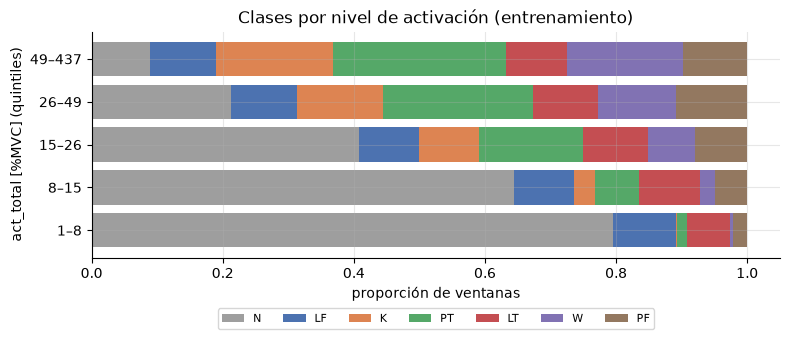

In [7]:
kb = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf")
kb.fit(df.loc[~is_test, ["act_total"]])
act_level = kb.transform(df[["act_total"]]).astype(int).ravel()
edges = kb.bin_edges_[0]
level_names = [f"{edges[i]:.0f}–{edges[i + 1]:.0f}" for i in range(len(edges) - 1)]

tab = pd.crosstab(pd.Series(act_level[~is_test], name="nivel"), df.label[~is_test]).reindex(columns=LABEL_ORDER)
share = tab.div(tab.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 3.6))
left = np.zeros(len(share))
for c in LABEL_ORDER:
    ax.barh(level_names, share[c], left=left, color=CLASS_COLORS[c], label=c)
    left += share[c].to_numpy()
ax.set(xlabel="proporción de ventanas", ylabel="act_total [%MVC] (quintiles)", title="Clases por nivel de activación (entrenamiento)")
ax.legend(ncol=7, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()

# 5. Transformación

Muchos modelos (regresión logística, ANOVA, PCA, FA) funcionan mejor con variables aproximadamente simétricas. Las amplitudes EMG suelen tener colas largas a la derecha: la mayor parte del tiempo hay poca activación y a veces mucha. Primero se mide la asimetría (*skewness*) de cada característica en entrenamiento.

In [8]:
skew = df.loc[~is_test, FEATURES].skew()
summary = pd.DataFrame({"familia": pd.Series(FAMILY), "skew": skew})
(summary.assign(asimetrica=summary["skew"].abs() > 1)
        .groupby("familia").agg(n=("skew", "size"), asimétricas_más_de_1=("asimetrica", "sum"),
                                skew_mediana=("skew", "median"), skew_máx=("skew", "max")).round(2))

,n,asimétricas_más_de_1,skew_mediana,skew_máx
familia,,,,
activación (contexto 4 s),24,16,1.97,10.54
activación (último s),40,35,2.87,23.59
forma de onda / frecuencia (EMG crudo),32,16,0.41,1.38
patrón entre canales,11,7,1.20,2.30


Se comparan las transformaciones de la rúbrica sobre una característica representativa, `act_mean_ch1`:

- **log** y **raíz cuadrada:** simples, pero con una potencia fija.
- **Box-Cox:** estima la potencia óptima, pero sólo admite valores **positivos**.
- **Yeo-Johnson:** estima la potencia y admite **ceros y negativos**.

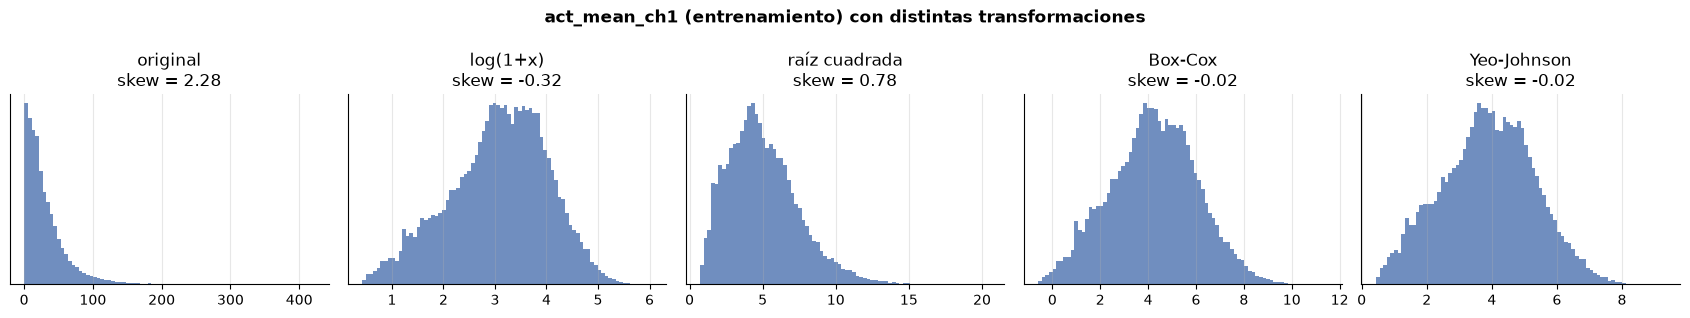

In [9]:
x = df.loc[~is_test, "act_mean_ch1"].to_numpy()
variants = {
    "original": x,
    "log(1+x)": np.log1p(x),
    "raíz cuadrada": np.sqrt(x),
    "Box-Cox": stats.boxcox(np.clip(x, 1e-6, None))[0],         # Box-Cox exige x > 0
    "Yeo-Johnson": PowerTransformer(method="yeo-johnson", standardize=False).fit_transform(x[:, None]).ravel(),
}
fig, axes = plt.subplots(1, 5, figsize=(17, 3.2))
for ax, (name, v) in zip(axes, variants.items()):
    ax.hist(v, bins=80, color="#4c72b0", alpha=0.8)
    ax.set(title=f"{name}\nskew = {stats.skew(v):.2f}", yticks=[])
fig.suptitle("act_mean_ch1 (entrenamiento) con distintas transformaciones", fontweight="bold")
fig.tight_layout()

**Decisión:** se aplica **Yeo-Johnson** (`PowerTransformer`, ajustado sólo con entrenamiento) a todas las características con |skew| > 1.

- Logra una simetría igual o mejor que Box-Cox y mucho mejor que log o raíz, que usan una potencia fija.
- Varias características son **negativas o cero** por definición, como las pendientes (`act_slope`, `ctx_slope`) y `act_change`. Box-Cox no las admite y Yeo-Johnson sí, así que se puede usar **una sola** transformación para todas.
- Estima una potencia distinta para cada característica, en lugar de imponer la misma a todas.

Las características con |skew| ≤ 1 se dejan como están: transformarlas no aporta y dificulta su interpretación.

In [10]:
SKEWED = skew.index[skew.abs() > 1].tolist()
X = df[FEATURES].copy()
power = PowerTransformer(method="yeo-johnson", standardize=False).fit(X.loc[~is_test, SKEWED])
X[SKEWED] = power.transform(X[SKEWED])

skew_after = X.loc[~is_test, FEATURES].skew()
print(f"{len(SKEWED)} de {len(FEATURES)} características transformadas con Yeo-Johnson")
print(f"|skew| mediana: {skew.abs().median():.2f} -> {skew_after.abs().median():.2f}   |   "
      f"características con |skew| > 1: {(skew.abs() > 1).sum()} -> {(skew_after.abs() > 1).sum()}")

74 de 107 características transformadas con Yeo-Johnson
|skew| mediana: 1.54 -> 0.05   |   características con |skew| > 1: 74 -> 0


# 6. Escalamiento

Hay dos problemas de escala distintos, y cada uno se resuelve con una técnica diferente.

**1. Diferencias entre sujetos.** El EDA mostró que la amplitud cruda varía ~10× entre sujetos y que la frecuencia de muestreo y la colocación de electrodos cambian de una sesión a otra. Aunque `Norm_RMS` ya está en %MVC, el gráfico de abajo muestra que el nivel de cada característica sigue dependiendo del sujeto. Si no se corrige, el modelo aprende "quién es el sujeto" en lugar de "qué está haciendo", y no generaliza a sujetos nuevos.

→ **Estandarización por sujeto:** a cada sujeto se le resta su media y se divide entre su desviación estándar, calculadas con **todas sus ventanas y sin usar etiquetas**. En los sujetos de prueba esto equivale a una calibración con sus propios datos sin etiquetar, algo factible en una aplicación real (unos minutos de registro antes de usar el sistema).

**2. Diferencias entre características.** Las unidades son muy distintas: %MVC, %MVC/s, Hz, conteos por segundo y fracciones.

→ **Estandarización global** (`StandardScaler`, media 0 y desviación 1, ajustado con entrenamiento) antes de los modelos lineales, ANOVA, PCA y FA, que son sensibles a la escala.

→ **Min–max a [0, 1]** sólo para el **umbral de varianza** (7.1): ahí se necesita que las varianzas sean comparables entre características, y con la estandarización todas valdrían 1.

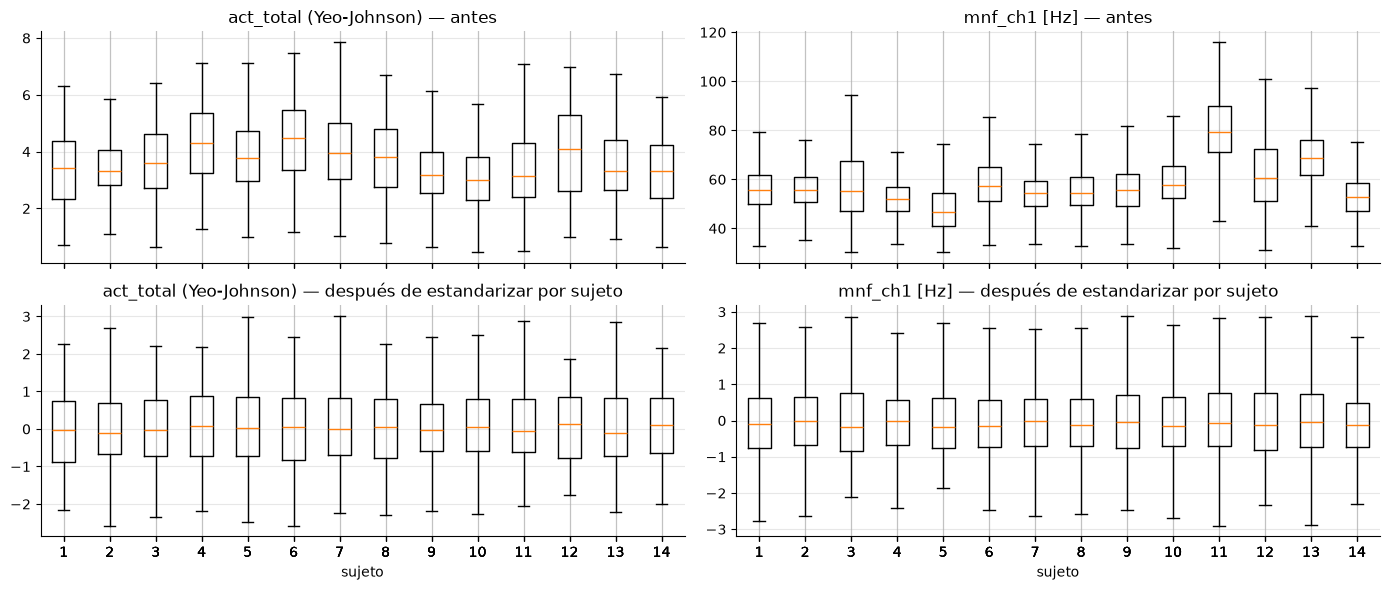

In [11]:
def standardize_by_subject(frame, subjects):
    """z-score de cada columna dentro de cada sujeto (sin usar etiquetas)."""
    g = frame.groupby(subjects)
    return (frame - g.transform("mean")) / g.transform("std").replace(0, 1)


X_subj = standardize_by_subject(X, df.subject)

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
for col, (feat, title) in enumerate([("act_total", "act_total (Yeo-Johnson)"), ("mnf_ch1", "mnf_ch1 [Hz]")]):
    for row, (frame, stage) in enumerate([(X, "antes"), (X_subj, "después de estandarizar por sujeto")]):
        ax = axes[row, col]
        data = [frame.loc[(df.subject == s).to_numpy(), feat] for s in sorted(df.subject.unique())]
        ax.boxplot(data, tick_labels=sorted(df.subject.unique()), showfliers=False)
        ax.set(title=f"{title} — {stage}")
for ax in axes[1]:
    ax.set_xlabel("sujeto")
fig.tight_layout()

Después de estandarizar por sujeto, todos los sujetos quedan centrados en el mismo nivel. Las diferencias que quedan **dentro** de cada sujeto son las que distinguen actividades. Las secciones siguientes trabajan con esta versión (`X_subj`), y en la sección 9 se mide cuánto aporta comparándola con no hacerlo.

# 7. Selección de características por filtrado

Los métodos de filtrado evalúan cada característica por su cuenta, sin entrenar el modelo final: son rápidos y no dependen del clasificador. Se aplican en cadena y siempre con los sujetos de entrenamiento:

1. **Umbral de varianza:** quita las características casi constantes.
2. **Correlación:** quita las redundantes.
3. **ANOVA F**, **chi-cuadrado** e **información mutua:** ordenan las restantes por su relación con la clase.
4. **Número de características:** se elige con validación cruzada por sujeto.

### 7.1 Umbral de varianza

Con min-max clásico se eliminarían 19: ['act_change', 'act_slope_ch1', 'act_slope_ch2', 'act_slope_ch3', 'act_slope_ch4', 'act_slope_ch5', 'act_slope_ch6', 'act_slope_ch7', 'act_slope_ch8', 'ctx_slope_ch1', 'ctx_slope_ch2', 'ctx_slope_ch3', 'ctx_slope_ch4', 'ctx_slope_ch5', 'ctx_slope_ch6', 'ctx_slope_ch7', 'ctx_slope_ch8', 'share_ch3', 'share_ch7']
Con min-max robusto se eliminan 0: []


,varianza min-max,varianza robusta,curtosis,ANOVA F
act_slope_ch1,0.0007,0.0174,24.7243,479.7914
ctx_slope_ch1,0.0031,0.0283,3.5769,2439.5406
act_change,0.0031,0.0302,4.3735,2701.9800
act_mean_ch1,0.0213,0.0535,-0.4801,3447.7256


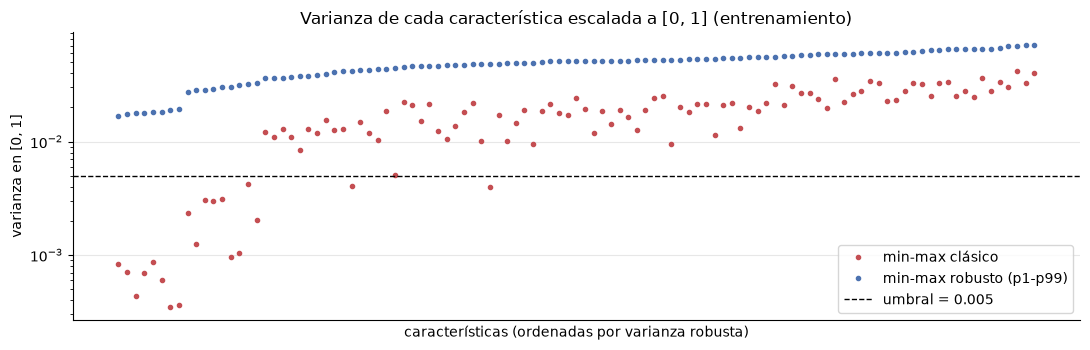

In [12]:
Xtr = X_subj.loc[~is_test, FEATURES]

# Min-max clásico: el mínimo y el máximo los fijan los valores más extremos
var_minmax = pd.Series(MinMaxScaler().fit_transform(Xtr).var(axis=0), index=FEATURES)
# Min-max robusto: se recorta cada característica a sus percentiles 1-99 antes de escalar a [0, 1]
q01, q99 = Xtr.quantile(0.01), Xtr.quantile(0.99)
var_robust = ((Xtr.clip(q01, q99, axis=1) - q01) / (q99 - q01)).var()

VAR_THRESHOLD = 0.005
KEEP_VAR = [f for f in FEATURES if var_robust[f] > VAR_THRESHOLD]

order_v = var_robust.sort_values().index
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(range(len(order_v)), var_minmax[order_v].to_numpy(), "o", ms=3, color="#c44e52", label="min-max clásico")
ax.plot(range(len(order_v)), var_robust[order_v].to_numpy(), "o", ms=3, color="#4c72b0", label="min-max robusto (p1-p99)")
ax.axhline(VAR_THRESHOLD, color="k", ls="--", lw=1, label=f"umbral = {VAR_THRESHOLD}")
ax.set(yscale="log", xlabel="características (ordenadas por varianza robusta)", ylabel="varianza en [0, 1]", xticks=[],
       title="Varianza de cada característica escalada a [0, 1] (entrenamiento)")
ax.legend()
fig.tight_layout()

naive_drop = sorted(var_minmax.index[var_minmax <= VAR_THRESHOLD])
print(f"Con min-max clásico se eliminarían {len(naive_drop)}: {naive_drop}")
print(f"Con min-max robusto se eliminan {len(FEATURES) - len(KEEP_VAR)}: {sorted(set(FEATURES) - set(KEEP_VAR))}")
pd.DataFrame({"varianza min-max": var_minmax, "varianza robusta": var_robust,
              "curtosis": Xtr.kurt(), "ANOVA F": f_classif(Xtr, y[~is_test])[0]}
             ).loc[["act_slope_ch1", "ctx_slope_ch1", "act_change", "act_mean_ch1"]].round(4)

**Decisión: el umbral se aplica con min–max robusto.** El min–max clásico es muy sensible a los valores atípicos: un solo valor extremo fija el máximo y comprime todo lo demás cerca de 0, así que una característica útil *parece* constante.

Eso pasa exactamente con las **pendientes** (`act_slope`, `ctx_slope`) y `act_change`:

- **Son simétricas pero de colas muy largas** (curtosis de hasta ~25): casi siempre la activación cambia poco, pero en los arranques de un levantamiento cambia muchísimo.
- **Con min–max clásico tienen varianza < 0.005**, y el umbral eliminaría las 19.
- **Pero son informativas:** su ANOVA F (tabla de arriba) está en el rango de las características útiles, y conceptualmente son las que distinguen levantar de colocar (sección 3.1).

Recortando a los percentiles 1–99 antes de escalar, la varianza refleja la dispersión **típica** de la característica, no la de sus extremos. El umbral de 0.005 equivale a que la característica casi no se mueve de su valor habitual. Que con el criterio robusto **no se elimine ninguna** significa que ninguna de las 107 es degenerada; el filtro que sí reduce dimensión en este problema es el de correlación (7.3).

### 7.2 ANOVA F, chi-cuadrado e información mutua

Tres criterios distintos para medir la relación de cada característica con la clase:

- **ANOVA F** (`f_classif`): compara la variación de las **medias por clase** con la variación dentro de cada clase. Supone relaciones lineales y distribuciones aproximadamente normales, que es parte de por qué se transformaron las características en la sección 5.
- **Chi-cuadrado:** prueba de independencia sobre la tabla de contingencia **intervalo × clase**, discretizando cada característica en 5 quintiles (como en 4.1). La intensidad se resume con la **V de Cramér** (0 = independiente, 1 = asociación perfecta). `chi2` de scikit-learn no se usa porque asume conteos no negativos, y aquí las características son continuas.
- **Información mutua:** capta también relaciones **no lineales** (por ejemplo, una característica que es alta tanto en `LF` como en `PF` y baja en las demás). Se estima con una submuestra estratificada de 20,000 ventanas para que sea rápida.

Correlación de Spearman entre los rankings de los tres criterios:


,ANOVA F,V de Cramér (chi²),información mutua
ANOVA F,1.00,0.9,0.81
V de Cramér (chi²),0.90,1.0,0.90
información mutua,0.81,0.9,1.00


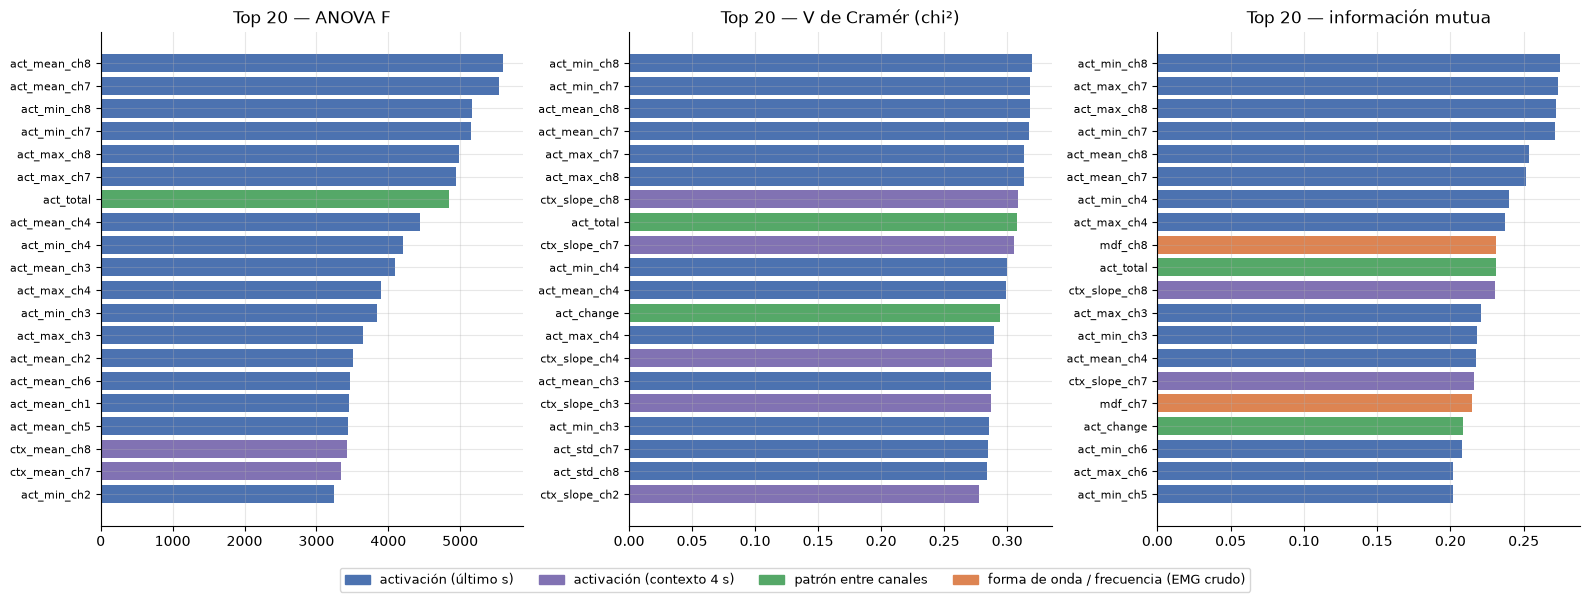

In [13]:
Xtr = X_subj.loc[~is_test, KEEP_VAR]
ytr = y[~is_test]

F_stat, _ = f_classif(Xtr, ytr)

kb_all = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf").fit(Xtr)
Xtr_bins = kb_all.transform(Xtr).astype(int)
cramer = []
for j in range(Xtr_bins.shape[1]):
    table = pd.crosstab(Xtr_bins[:, j], ytr).to_numpy()
    chi2_stat = stats.chi2_contingency(table)[0]
    cramer.append(np.sqrt(chi2_stat / (table.sum() * (min(table.shape) - 1))))

rng = np.random.default_rng(SEED)
sub = rng.choice(len(Xtr), size=min(20_000, len(Xtr)), replace=False)
mi = mutual_info_classif(Xtr.to_numpy()[sub], ytr[sub], random_state=SEED)

scores = pd.DataFrame({"ANOVA F": F_stat, "V de Cramér (chi²)": cramer, "información mutua": mi,
                       "familia": [FAMILY[f] for f in KEEP_VAR]}, index=KEEP_VAR)

FAMILY_COLORS = {"activación (último s)": "#4c72b0", "activación (contexto 4 s)": "#8172b3",
                 "patrón entre canales": "#55a868", "forma de onda / frecuencia (EMG crudo)": "#dd8452"}
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col in zip(axes, ["ANOVA F", "V de Cramér (chi²)", "información mutua"]):
    top = scores.sort_values(col).tail(20)
    ax.barh(top.index, top[col], color=[FAMILY_COLORS[f] for f in top.familia])
    ax.set(title=f"Top 20 — {col}")
    ax.tick_params(axis="y", labelsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
fig.legend(handles, FAMILY_COLORS.keys(), ncol=4, loc="lower center", fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 1))

print("Correlación de Spearman entre los rankings de los tres criterios:")
scores[["ANOVA F", "V de Cramér (chi²)", "información mutua"]].corr(method="spearman").round(2)

### 7.3 Correlación entre características

Muchas características son variantes de la misma información, por ejemplo la media, el máximo y el mínimo de la activación del mismo canal. Las parejas muy correlacionadas no aportan información nueva, pero sí aumentan el almacenamiento, el tiempo de entrenamiento y la inestabilidad de los coeficientes de un modelo lineal (multicolinealidad).

**Regla:** si dos características tienen |r de Pearson| > 0.90 en entrenamiento, se elimina la de **menor ANOVA F**. Así, de cada grupo redundante se queda la más informativa sobre la clase.

93 parejas con |r| > 0.9; se eliminan 45 características y quedan 62


,eliminadas por familia
activación (último s),22
activación (contexto 4 s),12
forma de onda / frecuencia (EMG crudo),10
patrón entre canales,1


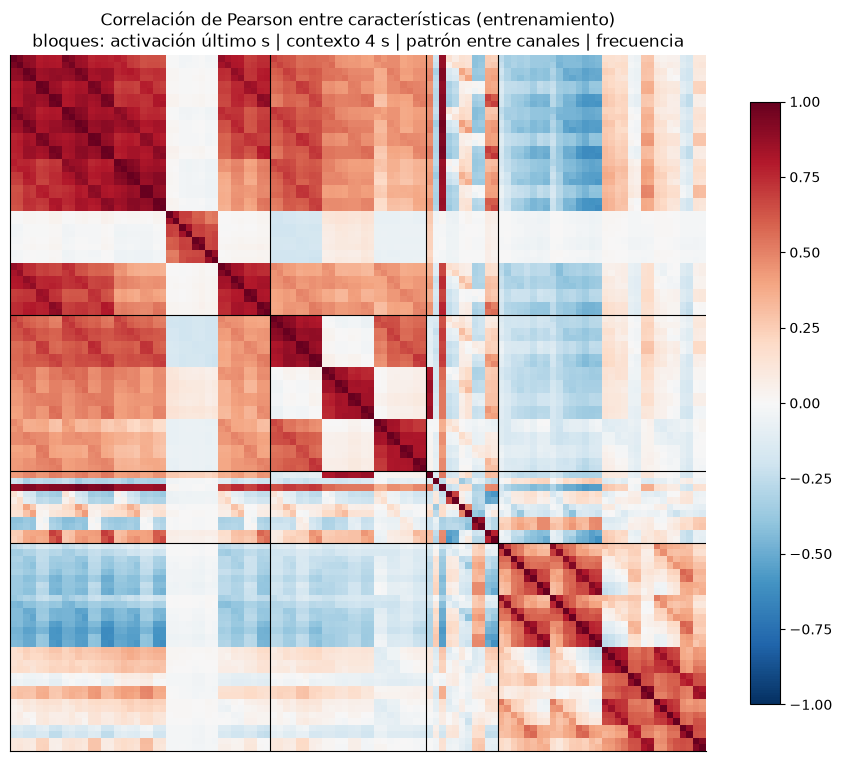

In [14]:
CORR_THRESHOLD = 0.90
corr = X_subj.loc[~is_test, KEEP_VAR].corr()

order = scores.sort_values("ANOVA F", ascending=False).index          # de más a menos relevante
KEEP_CORR = []
for f in order:
    if all(abs(corr.loc[f, g]) <= CORR_THRESHOLD for g in KEEP_CORR):
        KEEP_CORR.append(f)
dropped = [f for f in KEEP_VAR if f not in KEEP_CORR]

# Mapa de calor ordenado por familia y tipo de característica
ordered = sorted(KEEP_VAR, key=lambda f: (list(FAMILY_COLORS).index(FAMILY[f]), f.split("_ch")[0], f))
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.loc[ordered, ordered], cmap="RdBu_r", vmin=-1, vmax=1)
bounds = np.cumsum([sum(FAMILY[f] == fam for f in ordered) for fam in FAMILY_COLORS])[:-1]
for b in bounds:
    ax.axhline(b - 0.5, color="k", lw=0.8); ax.axvline(b - 0.5, color="k", lw=0.8)
ax.set(xticks=[], yticks=[], title="Correlación de Pearson entre características (entrenamiento)\n"
       "bloques: activación último s | contexto 4 s | patrón entre canales | frecuencia")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

n_pairs = int((np.triu(corr.abs().to_numpy(), 1) > CORR_THRESHOLD).sum())
print(f"{n_pairs} parejas con |r| > {CORR_THRESHOLD}; se eliminan {len(dropped)} características y quedan {len(KEEP_CORR)}")
pd.Series([FAMILY[f] for f in dropped]).value_counts().rename("eliminadas por familia").to_frame()

### 7.4 ¿Cuántas características conservar?

Tras los filtros de varianza y correlación, las características restantes se ordenan por **ANOVA F** y se prueba conservar las *k* mejores. El valor de *k* se elige con **validación cruzada agrupada por sujeto** (`GroupKFold`, 4 particiones con los sujetos 1–12): cada partición evalúa en sujetos que no vio, igual que la evaluación final. Los sujetos 13 y 14 **no participan** en esta elección.

El clasificador es el mismo del notebook 01: regresión logística multinomial con `class_weight="balanced"`, sobre las características estandarizadas.

Validación cruzada: 28 s


k,5,10,15,20,25,30,40,50,60,62
F1 macro (CV),0.342,0.388,0.408,0.410,0.413,0.420,0.433,0.437,0.438,0.438
std,0.025,0.034,0.034,0.034,0.037,0.041,0.046,0.046,0.049,0.049


Seleccionadas 40 características: ['act_mean_ch8', 'act_min_ch7', 'act_mean_ch3', 'act_mean_ch6', 'ctx_mean_ch8', 'act_min_ch2', 'act_min_ch5', 'act_max_ch2', 'act_std_ch7', 'ctx_slope_ch8', 'ctx_mean_ch4', 'act_change', 'ctx_slope_ch3', 'act_std_ch4', 'ctx_slope_ch2', 'ctx_slope_ch6', 'share_ch8', 'act_std_ch2', 'ctx_mean_ch2', 'mnf_ch6', 'ctx_mean_ch6', 'share_ch7', 'act_std_ch5', 'mnf_ch8', 'mnf_ch4', 'mnf_ch3', 'mnf_ch2', 'mdf_ch5', 'mdf_ch7', 'act_slope_ch8', 'act_slope_ch7', 'mnf_ch1', 'ctx_std_ch7', 'ctx_std_ch4', 'act_slope_ch3', 'act_slope_ch4', 'act_slope_ch6', 'share_ch5', 'share_ch6', 'share_ch1']


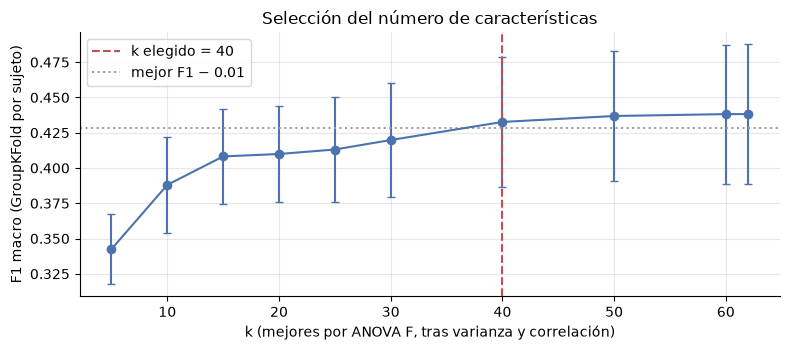

In [15]:
def make_clf():
    return LogisticRegression(max_iter=2000, class_weight="balanced")


def cv_f1(cols, n_splits=4):
    """F1 macro medio con GroupKFold por sujeto, sólo con los sujetos de entrenamiento."""
    Xc, yc, gc = X_subj.loc[~is_test, cols].to_numpy(), y[~is_test], df.subject[~is_test].to_numpy()
    out = []
    for tr, va in GroupKFold(n_splits=n_splits).split(Xc, yc, gc):
        sc = StandardScaler().fit(Xc[tr])
        clf = make_clf().fit(sc.transform(Xc[tr]), yc[tr])
        out.append(f1_score(yc[va], clf.predict(sc.transform(Xc[va])), average="macro"))
    return np.mean(out), np.std(out)


ranked = scores.loc[KEEP_CORR].sort_values("ANOVA F", ascending=False).index.tolist()
K_GRID = [k for k in [5, 10, 15, 20, 25, 30, 40, 50, 60] if k < len(ranked)] + [len(ranked)]
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv = pd.DataFrame([(k, *cv_f1(ranked[:k])) for k in K_GRID], columns=["k", "F1 macro (CV)", "std"]).set_index("k")
print(f"Validación cruzada: {time.time() - t0:.0f} s")
display(cv.round(3).T)

best_f1 = cv["F1 macro (CV)"].max()
K_SELECTED = int(cv.index[cv["F1 macro (CV)"] >= best_f1 - 0.01].min())     # el k más pequeño a <= 0.01 del mejor
SELECTED = ranked[:K_SELECTED]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.errorbar(cv.index, cv["F1 macro (CV)"], yerr=cv["std"], marker="o", capsize=3, color="#4c72b0")
ax.axvline(K_SELECTED, color="#c44e52", ls="--", label=f"k elegido = {K_SELECTED}")
ax.axhline(best_f1 - 0.01, color="#9e9e9e", ls=":", label="mejor F1 − 0.01")
ax.set(xlabel="k (mejores por ANOVA F, tras varianza y correlación)", ylabel="F1 macro (GroupKFold por sujeto)",
       title="Selección del número de características")
ax.legend()
fig.tight_layout()
print(f"Seleccionadas {K_SELECTED} características:", SELECTED)

**Criterio de parsimonia:** se elige el *k* **más pequeño** cuyo F1 de validación esté a menos de 0.01 del mejor. Con 12 sujetos, diferencias menores que eso están dentro del ruido entre particiones (ver las barras de error). Menos características significa menos almacenamiento, un modelo más simple y un entrenamiento más rápido, sin perder desempeño.

# 8. Extracción de características

La selección **conserva** algunas de las características originales; la extracción las **combina** en variables nuevas. Ambos métodos se ajustan con entrenamiento sobre todas las características que pasaron el umbral de varianza, estandarizadas: PCA y FA manejan la correlación por sí mismos, así que no necesitan el filtro de correlación.

### 8.1 Análisis de componentes principales (PCA)

PCA encuentra direcciones ortogonales que capturan la **máxima varianza**. No usa las etiquetas: resume la información, pero no necesariamente la que distingue las clases.

107 características -> 17 componentes (90%), 30 (95%), Kaiser: 12


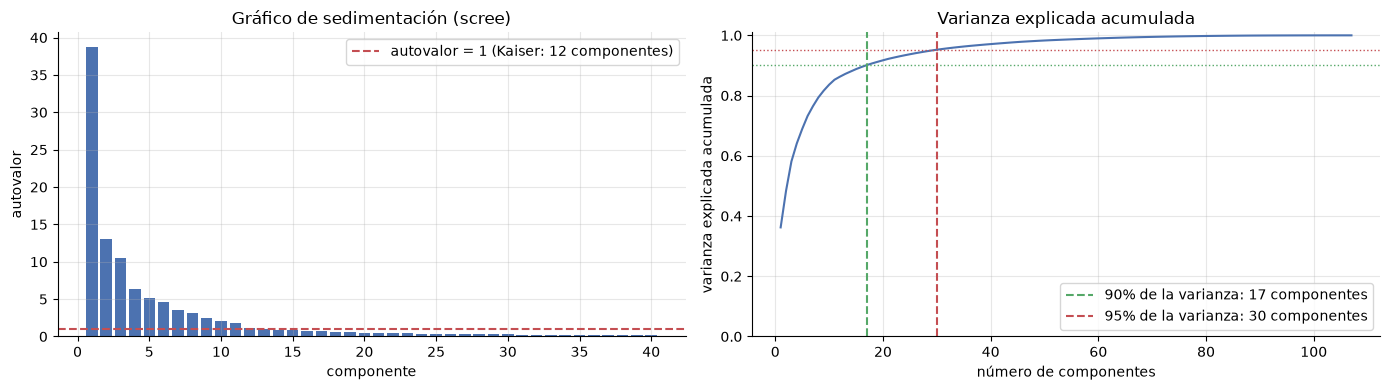

In [16]:
scaler_var = StandardScaler().fit(X_subj.loc[~is_test, KEEP_VAR])
Ztr = scaler_var.transform(X_subj.loc[~is_test, KEEP_VAR])
Zte = scaler_var.transform(X_subj.loc[is_test, KEEP_VAR])

pca_full = PCA(random_state=SEED).fit(Ztr)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
N_PC90, N_PC95 = int(np.searchsorted(cumvar, 0.90) + 1), int(np.searchsorted(cumvar, 0.95) + 1)
N_KAISER = int((pca_full.explained_variance_ > 1).sum())          # autovalores > 1 (criterio de Kaiser)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_show = 40
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_[:n_show], color="#4c72b0")
axes[0].axhline(1, color="#c44e52", ls="--", label=f"autovalor = 1 (Kaiser: {N_KAISER} componentes)")
axes[0].set(xlabel="componente", ylabel="autovalor", title="Gráfico de sedimentación (scree)")
axes[0].legend()
axes[1].plot(range(1, len(cumvar) + 1), cumvar, color="#4c72b0")
for n, lvl, c in [(N_PC90, 0.90, "#55a868"), (N_PC95, 0.95, "#c44e52")]:
    axes[1].axhline(lvl, color=c, ls=":", lw=1)
    axes[1].axvline(n, color=c, ls="--", label=f"{lvl:.0%} de la varianza: {n} componentes")
axes[1].set(xlabel="número de componentes", ylabel="varianza explicada acumulada", ylim=(0, 1.01),
            title="Varianza explicada acumulada")
axes[1].legend()
fig.tight_layout()
print(f"{len(KEEP_VAR)} características -> {N_PC90} componentes (90%), {N_PC95} (95%), Kaiser: {N_KAISER}")

**Interpretación de las primeras componentes:** las 6 cargas con mayor magnitud de cada una indican qué combina cada componente. La proyección sobre las dos primeras muestra cuánto separan las clases por sí solas.

,PC1,PC2,PC3,PC4
0,act_total (+0.16),zc_ch4 (+0.22),act_change (+0.20),mnf_ch8 (+0.19)
1,act_mean_ch3 (+0.15),zc_ch7 (+0.22),ctx_std_ch1 (-0.19),mdf_ch8 (+0.19)
2,act_mean_ch7 (+0.15),zc_ch3 (+0.22),ctx_std_ch2 (-0.19),mdf_ch7 (+0.18)
3,act_mean_ch4 (+0.15),zc_ch8 (+0.22),ctx_std_ch3 (-0.18),mnf_ch7 (+0.18)
4,act_mean_ch8 (+0.15),zc_ch5 (+0.21),ctx_mean_ch1 (-0.18),act_std_ch5 (+0.16)
5,act_max_ch3 (+0.15),ssc_ch5 (+0.21),ctx_std_ch4 (-0.18),act_std_ch6 (+0.16)


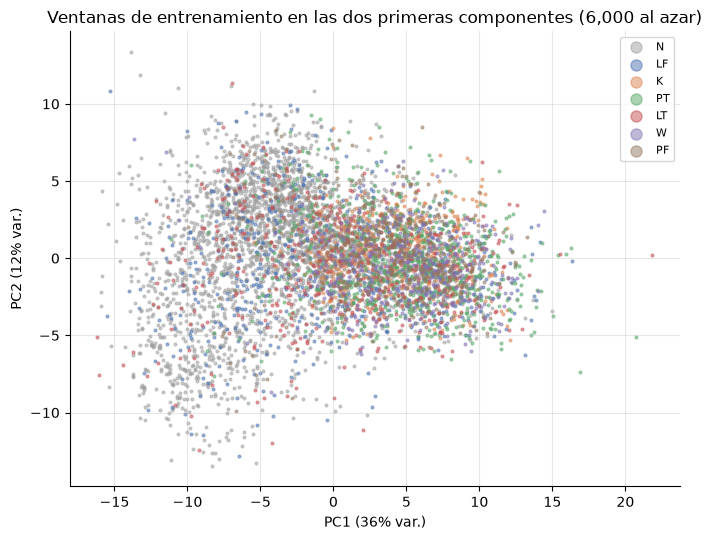

In [17]:
loadings = pd.DataFrame(pca_full.components_[:4].T, index=KEEP_VAR, columns=[f"PC{i}" for i in range(1, 5)])
top_loadings = pd.DataFrame({pc: [f"{f} ({loadings.loc[f, pc]:+.2f})" for f in loadings[pc].abs().nlargest(6).index]
                             for pc in loadings.columns})
display(top_loadings)

proj = pca_full.transform(Ztr)[:, :2]
sub = np.random.default_rng(SEED).choice(len(proj), size=6000, replace=False)
fig, ax = plt.subplots(figsize=(7, 5.5))
for i, c in enumerate(LABEL_ORDER):
    m = ytr[sub] == i
    ax.scatter(proj[sub][m, 0], proj[sub][m, 1], s=4, alpha=0.5, color=CLASS_COLORS[c], label=c)
ax.set(xlabel=f"PC1 ({pca_full.explained_variance_ratio_[0]:.0%} var.)",
       ylabel=f"PC2 ({pca_full.explained_variance_ratio_[1]:.0%} var.)",
       title="Ventanas de entrenamiento en las dos primeras componentes (6,000 al azar)")
ax.legend(markerscale=4, fontsize=8)
fig.tight_layout()

### 8.2 Análisis factorial (FA)

A diferencia de PCA, el análisis factorial supone que las características observadas son **efectos de unos pocos factores latentes**, más un ruido propio de cada característica. Por ejemplo: "nivel de esfuerzo", "tendencia de la activación" o "contenido de frecuencia". Por eso busca la estructura de **covarianza compartida** y no toda la varianza.

- **Número de factores:** criterio de Kaiser sobre la matriz de correlación (autovalores > 1), calculado arriba.
- **Rotación varimax:** hace que cada característica cargue fuerte en pocos factores, lo que facilita **interpretarlos**.

FA con 12 factores ajustado en 1 s


,F1,F2,F3,F4,F5,F6,F7,F8
0,act_min_ch3 (+0.89),act_change (-0.87),mdf_ch5 (-0.86),act_std_ch6 (+0.79),ssc_ch4 (-0.86),ctx_std_ch3 (+0.84),share_ch1 (+0.79),share_ch5 (+0.81)
1,act_min_ch6 (+0.89),ctx_slope_ch4 (-0.85),mdf_ch6 (-0.84),act_std_ch5 (+0.78),ssc_ch3 (-0.85),ctx_std_ch4 (+0.84),share_ch8 (-0.71),share_ch6 (+0.79)
2,act_min_ch5 (+0.89),ctx_slope_ch3 (-0.85),mnf_ch5 (-0.83),act_std_ch4 (+0.75),ssc_ch2 (-0.82),ctx_std_ch6 (+0.83),share_ch2 (+0.69),share_ch1 (-0.37)
3,act_min_ch2 (+0.88),ctx_slope_ch8 (-0.84),mnf_ch6 (-0.80),act_std_ch2 (+0.75),ssc_ch1 (-0.81),ctx_std_ch5 (+0.83),share_ch7 (-0.68),share_ch2 (-0.33)


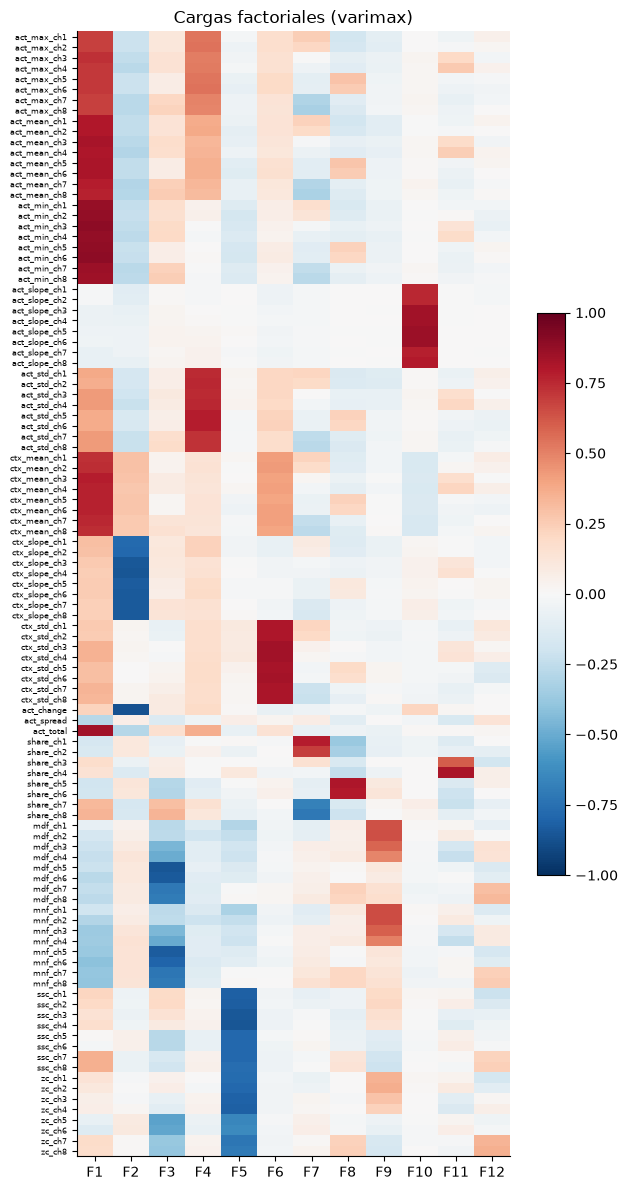

In [18]:
t0 = time.time()
fa = FactorAnalysis(n_components=N_KAISER, rotation="varimax", random_state=SEED).fit(Ztr)
print(f"FA con {N_KAISER} factores ajustado en {time.time() - t0:.0f} s")

fa_load = pd.DataFrame(fa.components_.T, index=KEEP_VAR, columns=[f"F{i}" for i in range(1, N_KAISER + 1)])
fa_load = fa_load[fa_load.abs().sum().sort_values(ascending=False).index]          # factores por peso total
fa_load.columns = [f"F{i}" for i in range(1, N_KAISER + 1)]
ordered = sorted(KEEP_VAR, key=lambda f: (list(FAMILY_COLORS).index(FAMILY[f]), f.split("_ch")[0], f))

fig, ax = plt.subplots(figsize=(min(1 + 0.45 * N_KAISER, 14), 12))
im = ax.imshow(fa_load.loc[ordered], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(xticks=range(N_KAISER), xticklabels=fa_load.columns, yticks=range(len(ordered)), title="Cargas factoriales (varimax)")
ax.set_yticklabels(ordered, fontsize=6)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.5)
fig.tight_layout()

pd.DataFrame({f: [f"{n} ({fa_load.loc[n, f]:+.2f})" for n in fa_load[f].abs().nlargest(4).index]
              for f in fa_load.columns[:8]})

**Lectura de los factores:** con la rotación varimax, cada factor agrupa casi siempre **una sola familia y un solo tipo** de característica de los 8 canales. Esto indica que la redundancia principal está **entre canales** (todos los músculos se activan juntos) y no entre tipos de característica:

| Factor | Cargas altas | Interpretación |
| :--- | :--- | :--- |
| F1 | media, mínimo y máximo de la activación (último s y 4 s) | **nivel de esfuerzo** |
| F2 | `ctx_slope`, `act_change` (con signo negativo) | **tendencia**: ¿la activación sube o baja? |
| F3 | `mnf`, `mdf` (canales 3–8) | **contenido de frecuencia** del EMG |
| F4 | `act_std` | **variabilidad** de la activación en el último segundo |
| F5 | `zc`, `ssc` | **cruces por cero y cambios de pendiente** |
| F6 | `ctx_std` | **variabilidad** en los 4 s |
| F7, F8, F11 | `share` | **patrón de reparto entre músculos** |
| F9 | `mnf`, `mdf` (canales 1–2) | frecuencia de los primeros canales |
| F10 | `act_slope` | tendencia **instantánea** (último segundo) |

(El orden exacto de los factores puede cambiar si se recalculan las características, pero los grupos son los mismos.)

# 9. Comparación: ¿cuánto se pierde y cuánto se ahorra?

Cada conjunto de características se evalúa con el mismo procedimiento: se entrena con los sujetos 1–12 y se prueba con el 13 y el 14, que es exactamente la evaluación del *linear probe* de `01_Pipeline_CPC.ipynb`. Para cada conjunto se reportan:

- **desempeño:** F1 macro y *balanced accuracy*;
- **complejidad:** número de variables;
- **almacenamiento:** MB de la matriz de entrenamiento en `float32`;
- **tiempo** de entrenamiento.

Además de los conjuntos de las secciones 7 y 8 se incluyen dos variantes que **justifican decisiones** anteriores:

- **sin estandarizar por sujeto** (sólo Yeo-Johnson + escalado global), para medir el efecto de la sección 6;
- **seleccionadas + contexto** (codificación de la sección 4), separando el contexto **del ensayo** (tarea, lado, ritmo, carga) del contexto **del sujeto** (sexo, IMC), para medir qué aporta cada uno.

In [19]:
def evaluate(name, Xtrain, Xtest):
    sc = StandardScaler().fit(Xtrain)
    Xtrain, Xtest = sc.transform(Xtrain).astype(np.float32), sc.transform(Xtest).astype(np.float32)
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf = make_clf().fit(Xtrain, y[~is_test])
    fit_s = time.time() - t0
    pred = clf.predict(Xtest)
    per_class = f1_score(y[is_test], pred, labels=range(len(LABEL_ORDER)), average=None, zero_division=0)
    return {"conjunto": name, "n variables": Xtrain.shape[1], "MB (train)": Xtrain.nbytes / 1e6,
            "tiempo de ajuste [s]": fit_s, "F1 macro": f1_score(y[is_test], pred, average="macro"),
            "balanced acc": balanced_accuracy_score(y[is_test], pred),
            **{f"F1 {c}": v for c, v in zip(LABEL_ORDER, per_class)}}


Xs_tr, Xs_te = X_subj.loc[~is_test], X_subj.loc[is_test]
pca95 = PCA(n_components=N_PC95, random_state=SEED).fit(Ztr)
ctx_tr, ctx_te = ctx_df.loc[~is_test], ctx_df.loc[is_test]
SUBJECT_CTX = ["sex_F", "imc"]                                  # del sujeto (Subjs_info.xlsx)
TRIAL_CTX = [c for c in CONTEXT if c not in SUBJECT_CTX]        # del ensayo (nombre del archivo)

results = pd.DataFrame([
    evaluate("Todas (señal)", Xs_tr[FEATURES], Xs_te[FEATURES]),
    evaluate("Todas, sin estandarizar por sujeto", X.loc[~is_test, FEATURES], X.loc[is_test, FEATURES]),
    evaluate("Varianza + correlación", Xs_tr[KEEP_CORR], Xs_te[KEEP_CORR]),
    evaluate(f"Seleccionadas (top {K_SELECTED} ANOVA)", Xs_tr[SELECTED], Xs_te[SELECTED]),
    evaluate(f"PCA ({N_PC95} comp., 95% var.)", pca95.transform(Ztr), pca95.transform(Zte)),
    evaluate(f"Análisis factorial ({N_KAISER} factores)", fa.transform(Ztr), fa.transform(Zte)),
    evaluate("Seleccionadas + contexto del ensayo", pd.concat([Xs_tr[SELECTED], ctx_tr[TRIAL_CTX]], axis=1),
             pd.concat([Xs_te[SELECTED], ctx_te[TRIAL_CTX]], axis=1)),
    evaluate("Seleccionadas + contexto del sujeto", pd.concat([Xs_tr[SELECTED], ctx_tr[SUBJECT_CTX]], axis=1),
             pd.concat([Xs_te[SELECTED], ctx_te[SUBJECT_CTX]], axis=1)),
]).set_index("conjunto")
results.iloc[:, :5].round(3)

,n variables,MB (train),tiempo de ajuste [s],F1 macro,balanced acc
conjunto,,,,,
Todas (señal),107,22.778,3.180,0.459,0.506
"Todas, sin estandarizar por sujeto",107,22.778,4.291,0.453,0.480
Varianza + correlación,62,13.199,1.053,0.462,0.510
Seleccionadas (top 40 ANOVA),40,8.515,0.929,0.461,0.512
"PCA (30 comp., 95% var.)",30,6.386,0.115,0.439,0.489
Análisis factorial (12 factores),12,2.555,0.102,0.412,0.465
Seleccionadas + contexto del ensayo,47,10.005,1.061,0.473,0.540
Seleccionadas + contexto del sujeto,42,8.941,1.076,0.412,0.458


**Referencias del notebook 01** (mismas ventanas, mismo split, mismo clasificador): el *linear probe* sobre la representación de **CPC con GRU** y las **features crudas** (media y desviación estándar de cada canal en el último segundo, 16 variables). Se leen de `_cache/probe_results_gru_lstm.csv`, generado por la sección 7 del notebook 01 con 50 Hz.

,F1 N,F1 LF,F1 K,F1 PT,F1 LT,F1 W,F1 PF
conjunto,,,,,,,
Todas (señal),0.718,0.419,0.504,0.393,0.437,0.377,0.366
"Todas, sin estandarizar por sujeto",0.755,0.431,0.535,0.349,0.412,0.299,0.391
Varianza + correlación,0.723,0.426,0.518,0.392,0.425,0.382,0.369
Seleccionadas (top 40 ANOVA),0.725,0.446,0.502,0.380,0.438,0.372,0.366
"PCA (30 comp., 95% var.)",0.715,0.406,0.491,0.370,0.385,0.374,0.335
Análisis factorial (12 factores),0.671,0.397,0.469,0.321,0.370,0.362,0.294
Seleccionadas + contexto del ensayo,0.686,0.439,0.565,0.363,0.448,0.415,0.395
Seleccionadas + contexto del sujeto,0.674,0.419,0.396,0.376,0.374,0.322,0.323


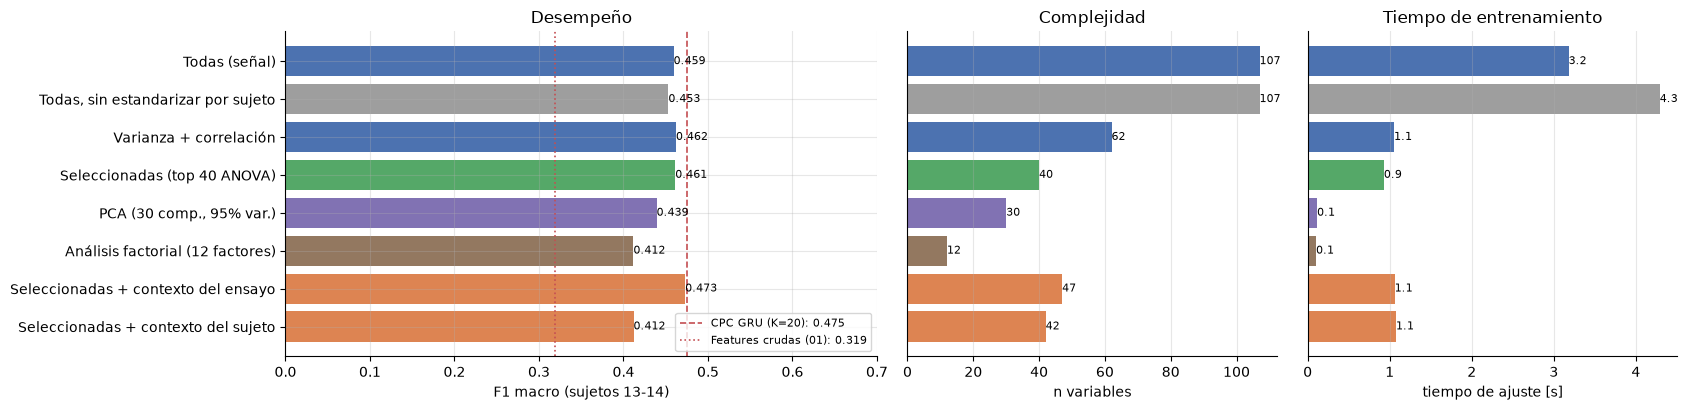

In [20]:
ref_csv = CACHE_DIR / "probe_results_gru_lstm.csv"
refs = {}
if ref_csv.exists():
    ref = pd.read_csv(ref_csv)
    gru = ref[(ref.g_ar == "GRU") & (ref["representación"] == "CPC")]
    best_gru = gru.loc[gru["F1 macro"].idxmax()]
    refs[f"CPC GRU (K={int(best_gru.K)})"] = best_gru["F1 macro"]
    refs["Features crudas (01)"] = ref.loc[ref["representación"] == "features crudas", "F1 macro"].iloc[0]
else:
    print(f"[aviso] No existe {ref_csv.name}: la gráfica se muestra sin las referencias del notebook 01.")

order_sets = results.index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), gridspec_kw={"width_ratios": [1.6, 1, 1]})
colors = ["#4c72b0", "#9e9e9e", "#4c72b0", "#55a868", "#8172b3", "#937860", "#dd8452", "#dd8452"]
bars = axes[0].barh(order_sets, results["F1 macro"], color=colors)
axes[0].bar_label(bars, fmt="%.3f", fontsize=8)
for (name, val), ls in zip(refs.items(), ["--", ":"]):
    axes[0].axvline(val, color="#c44e52", ls=ls, lw=1.2, label=f"{name}: {val:.3f}")
axes[0].set(xlabel="F1 macro (sujetos 13-14)", title="Desempeño", xlim=(0, max(0.7, results["F1 macro"].max() + 0.1)))
axes[0].invert_yaxis()
if refs:
    axes[0].legend(fontsize=8, loc="lower right")
for ax, col, title in [(axes[1], "n variables", "Complejidad"), (axes[2], "tiempo de ajuste [s]", "Tiempo de entrenamiento")]:
    b = ax.barh(order_sets, results[col], color=colors)
    ax.bar_label(b, fmt="%.0f" if col == "n variables" else "%.1f", fontsize=8)
    ax.set(xlabel=col, title=title, yticks=[])
    ax.invert_yaxis()
fig.tight_layout()

results[[f"F1 {c}" for c in LABEL_ORDER]].round(3)

# 10. Conclusiones

### Generación de características (sección 3)

- **Se generaron 107 características por ventana** desde tres fuentes:
  - la envolvente `Norm_RMS`: nivel, variabilidad y tendencia de la activación, en el último segundo y en los 4 s;
  - el reparto de la activación entre canales;
  - el EMG crudo filtrado: frecuencia media y mediana, cruces por cero y cambios de pendiente.
- **Las amplitudes son las más discriminantes según ANOVA,** sobre todo para separar `N` del resto.
- **Las tendencias (`ctx_slope`, `act_change`) aparecen en el top de chi-cuadrado e información mutua, pero no en el de ANOVA:** su relación con la clase no es una diferencia de medias, sino de forma (suben al levantar, bajan al colocar).
- **Las features de frecuencia** aportan 8 de las 40 seleccionadas.

### Codificación y discretización (sección 4)

- **Codificación según el tipo de variable:**
  - **nominales:** clase como entero 0–6 sin orden y tarea en *one-hot*;
  - **binarias:** lado y sexo;
  - **ordinales:** ritmo del metrónomo y nivel de carga.
- **IMC:** se generó a partir de masa y estatura.
- **La discretización de `act_total` en quintiles** muestra la relación con la actividad: en el quintil más bajo (1–8 %MVC) el 80% de las ventanas son `N`; en el más alto (49–437 %MVC) sólo el 9%, y dominan `PT`, `K` y `W`.

### Transformación (sección 5)

- **74 de 107 características tenían |skew| > 1,** casi todas de amplitud.
- **Se eligió Yeo-Johnson** sobre log, raíz y Box-Cox porque estima la potencia por característica y admite ceros y negativos (las pendientes).
- **Resultado:** la |skew| mediana bajó de 1.54 a 0.05, y no quedó ninguna característica con |skew| > 1.

### Escalamiento (sección 6)

- **La estandarización por sujeto (sin etiquetas) elimina las diferencias de nivel entre sujetos:** `mnf_ch1` del sujeto 11 estaba ~25 Hz por encima del resto.
- **Mejora la generalización a sujetos nuevos:** la *balanced accuracy* sube de 0.480 a 0.506 y el F1 de `W`, de 0.30 a 0.38.
- **Escalas auxiliares:** la estandarización global se usa antes de los modelos, y el min–max robusto, sólo para el umbral de varianza.

### Selección por filtrado (sección 7)

- **Umbral de varianza:** con min–max clásico habría eliminado 19 características **informativas** (todas las pendientes), sólo porque tienen colas largas. Con min–max robusto (p1–p99) no se eliminó ninguna: ninguna de las 107 es degenerada.
- **Correlación:** hubo 93 parejas con |r| > 0.9, sobre todo la misma medida en distintos canales. Al eliminar la menos relevante de cada pareja quedan **62 características (−42%)**, con el mismo F1 (0.462 contra 0.459) y un ajuste ~2.5× más rápido.
- **ANOVA, chi-cuadrado e información mutua coinciden bastante** (correlación de rangos de Spearman 0.81–0.90).
- **Validación cruzada por sujeto:** se eligieron **40 características**, el *k* más pequeño a menos de 0.01 del mejor. En los sujetos de prueba dan **F1 0.461, igual que las 107**, con 63% menos almacenamiento (8.5 contra 22.8 MB) y ~3× menos tiempo de ajuste.

### Extracción (sección 8)

- **PCA:**
  - la primera componente explica el 36% de la varianza y es el **nivel general de activación**;
  - bastan 17 componentes para el 90% y 30 para el 95%;
  - con 30 componentes el F1 baja sólo a 0.439 (−0.02), con un ajuste ~25× más rápido.
- **Análisis factorial:**
  - 12 factores (criterio de Kaiser) con significado físico claro: esfuerzo, tendencia, frecuencia, variabilidad, patrón entre músculos;
  - es la representación más compacta (2.6 MB, −89%), pero pierde más: F1 0.412;
  - su valor principal es **interpretativo**.

### Contexto del protocolo (sección 9)

- **El contexto del ensayo** (tarea, lado, ritmo y carga) sube el F1 de 0.461 a **0.473**, pero es información del protocolo que no estaría disponible en una aplicación real.
- **El contexto del sujeto** (sexo e IMC) lo **baja a 0.412**: con 12 sujetos de entrenamiento, esas variables casi identifican a cada persona y el modelo aprende rasgos que no se trasladan a sujetos nuevos. **No se recomienda usarlas.**

### Comparación con CPC (notebook 01)

Con las mismas ventanas, split y clasificador:

| Representación | F1 macro |
| :--- | :--- |
| Features crudas (media y desviación del último segundo, 16 variables) | 0.319 |
| **Ingeniería de características (40 variables seleccionadas)** | **0.461** |
| CPC con GRU, K=20 (256 dimensiones) | 0.475 |

Las características diseñadas a mano cierran casi toda la brecha entre las features crudas y la representación aprendida por CPC. La diferencia restante (0.014) está dentro del ruido esperable con sólo 2 sujetos de prueba.

### Recomendación

- **Conjunto final:** las **40 características seleccionadas**, con Yeo-Johnson y estandarización por sujeto. Conservan todo el desempeño con un tercio de las variables.
- **Si importa más la velocidad:** PCA con 30 componentes.
- **Siguientes pasos:**
  - combinar estas características con el contexto $c_t$ de CPC, porque podrían ser complementarias;
  - validar con *leave-one-subject-out* para tener una estimación más estable que la de 2 sujetos de prueba.